In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [54]:
DATA_PATH_P2S = Path("../../data/processed/pohang_to_seoul.parquet")
DATA_PATH_S2P = Path("../../data/processed/seoul_to_pohang.parquet")

df_p2s = pd.read_parquet(DATA_PATH_P2S)
df_s2p = pd.read_parquet(DATA_PATH_S2P)

print(f"Pohang → Seoul shape: {df_p2s.shape}")
print(f"Seoul → Pohang shape: {df_s2p.shape}")

datasets = {
    "Pohang → Seoul": df_p2s,
    "Seoul → Pohang": df_s2p
}

Pohang → Seoul shape: (2026, 8)
Seoul → Pohang shape: (2026, 8)


In [55]:
print("=== Dataset Info ===\n")
for name, df in datasets.items():
    print(f"{name}:")
    df.info()
    print()

=== Dataset Info ===

Pohang → Seoul:
<class 'pandas.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      2026 non-null   datetime64[us]
 1   origin_city               2026 non-null   str           
 2   destination_city          2026 non-null   str           
 3   rail_passengers           2026 non-null   int64         
 4   express_bus_passengers    2026 non-null   int64         
 5   intercity_bus_passengers  2026 non-null   int64         
 6   weekday                   2026 non-null   int32         
 7   is_weekend                2026 non-null   bool          
dtypes: bool(1), datetime64[us](1), int32(1), int64(3), str(2)
memory usage: 126.8 KB

Seoul → Pohang:
<class 'pandas.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dt

In [56]:
df_p2s.head()

,date,origin_city,destination_city,rail_passengers,express_bus_passengers,intercity_bus_passengers,weekday,is_weekend
0,2020-11-01,pohang,seoul,1173,514,34,6,True
1,2020-11-02,pohang,seoul,831,330,26,0,False
2,2020-11-03,pohang,seoul,701,292,28,1,False
3,2020-11-04,pohang,seoul,828,276,45,2,False
4,2020-11-05,pohang,seoul,942,337,39,3,False


In [57]:
df_s2p.head(100)

,date,origin_city,destination_city,rail_passengers,express_bus_passengers,intercity_bus_passengers,weekday,is_weekend
0,2020-11-01,seoul,pohang,1045,558,44,6,True
1,2020-11-02,seoul,pohang,853,353,39,0,False
2,2020-11-03,seoul,pohang,688,313,32,1,False
3,2020-11-04,seoul,pohang,800,266,27,2,False
4,2020-11-05,seoul,pohang,985,374,37,3,False
...,...,...,...,...,...,...,...,...
95,2021-02-04,seoul,pohang,654,300,28,3,False
96,2021-02-05,seoul,pohang,676,494,38,4,False
97,2021-02-06,seoul,pohang,638,319,17,5,True
98,2021-02-07,seoul,pohang,611,335,30,6,True


In [58]:
print("=== Date Range ===\n")
for name, df in datasets.items():
    print(f"{name}:")
    print(f"  Min date: {df['date'].min()}")
    print(f"  Max date: {df['date'].max()}")
    print()

=== Date Range ===

Pohang → Seoul:
  Min date: 2020-11-01 00:00:00
  Max date: 2026-05-19 00:00:00

Seoul → Pohang:
  Min date: 2020-11-01 00:00:00
  Max date: 2026-05-19 00:00:00



In [59]:
print("=== Duplicate Dates ===\n")
for name, df in datasets.items():
    duplicates = df["date"].duplicated().sum()
    print(f"{name}: {duplicates}")
    print()

=== Duplicate Dates ===

Pohang → Seoul: 0

Seoul → Pohang: 0



In [60]:
print("=== Missing Dates ===\n")
for name, df in datasets.items():
    expected_dates = pd.date_range(
        start=df["date"].min(),
        end=df["date"].max(),
        freq="D"
    )
    
    missing_dates = expected_dates.difference(df["date"])
    
    print(f"{name}:")
    print(f"  Missing dates: {len(missing_dates)}")
    if len(missing_dates) > 0:
        print(f"  First few: {missing_dates[:5].tolist()}")
    print()

=== Missing Dates ===

Pohang → Seoul:
  Missing dates: 0

Seoul → Pohang:
  Missing dates: 0



In [61]:
print("=== Missing Values ===\n")
for name, df in datasets.items():
    print(f"{name}:")
    missing = (df.isna().sum().sort_values(ascending=False))
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("  No missing values")
    print()

=== Missing Values ===

Pohang → Seoul:
  No missing values

Seoul → Pohang:
  No missing values



In [62]:
print("=== Numeric Columns Statistics ===\n")
for name, df in datasets.items():
    print(f"{name}:")
    numeric_cols = df.select_dtypes(include=np.number).columns
    print(df[numeric_cols].describe().T)
    print()

=== Numeric Columns Statistics ===

Pohang → Seoul:
                           count         mean         std    min      25%  \
rail_passengers           2026.0  1412.229023  438.431095  257.0  1149.25   
express_bus_passengers    2026.0   388.632280  254.360915  142.0   265.00   
intercity_bus_passengers  2026.0    28.741856   16.092234    4.0    18.00   
weekday                   2026.0     2.999013    2.001727    0.0     1.00   

                             50%      75%     max  
rail_passengers           1432.5  1664.00  3737.0  
express_bus_passengers     344.0   433.75  4477.0  
intercity_bus_passengers    26.0    35.00   199.0  
weekday                      3.0     5.00     6.0  

Seoul → Pohang:
                           count         mean         std    min     25%  \
rail_passengers           2026.0  1381.350444  428.989815  308.0  1112.0   
express_bus_passengers    2026.0   428.914116  277.298293  151.0   281.0   
intercity_bus_passengers  2026.0    26.772458   17.656980

In [63]:
print("=== Negative Values Check ===\n")
for name, df in datasets.items():
    print(f"{name}:")
    numeric_cols = df.select_dtypes(include=np.number).columns
    negative_exists = False
    for col in numeric_cols:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            print(f"  {col}: {n_neg} negative values")
            negative_exists = True
    if not negative_exists:
        print("  No negative values found.")
    print()

=== Negative Values Check ===

Pohang → Seoul:
  No negative values found.

Seoul → Pohang:
  No negative values found.



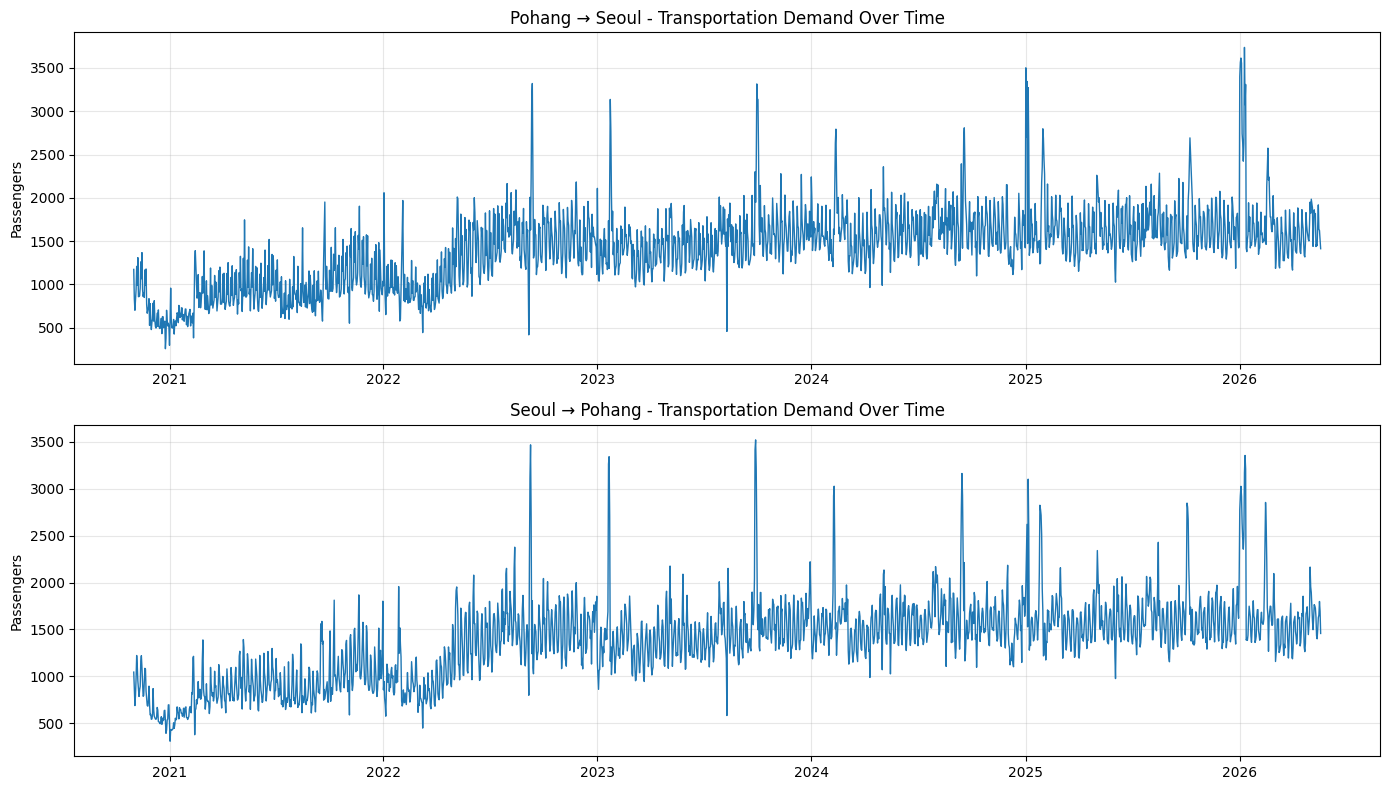

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Get passenger columns (assuming they're named 'express_bus_passengers' or similar)
for idx, (name, df) in enumerate(datasets.items()):
    # Find the passenger column
    pass_col = [col for col in df.columns if 'passenger' in col.lower()][0]
    
    axes[idx].plot(df["date"], df[pass_col], linewidth=1)
    axes[idx].set_title(f"{name} - Transportation Demand Over Time")
    axes[idx].set_ylabel("Passengers")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
print("=== Top 10 Busiest Days ===\n")
for name, df in datasets.items():
    pass_col = [col for col in df.columns if 'passenger' in col.lower()][0]
    print(f"{name}:")
    print(df.nlargest(10, pass_col)[["date", pass_col]])
    print()

=== Top 10 Busiest Days ===

Pohang → Seoul:
           date  rail_passengers
1895 2026-01-09             3737
1889 2026-01-03             3614
1888 2026-01-02             3564
1890 2026-01-04             3553
1522 2025-01-01             3501
1887 2026-01-01             3399
1524 2025-01-03             3344
680  2022-09-12             3320
1063 2023-09-30             3315
1897 2026-01-11             3309

Seoul → Pohang:
           date  rail_passengers
1061 2023-09-28             3521
677  2022-09-09             3468
1060 2023-09-27             3415
1896 2026-01-10             3355
811  2023-01-21             3342
810  2023-01-20             3264
1062 2023-09-29             3223
1897 2026-01-11             3210
1895 2026-01-09             3171
1413 2024-09-14             3163



In [66]:
print("=== Top 10 Quietest Days ===\n")
for name, df in datasets.items():
    pass_col = [col for col in df.columns if 'passenger' in col.lower()][0]
    print(f"{name}:")
    print(df.nsmallest(10, pass_col)[["date", pass_col]])
    print()

=== Top 10 Quietest Days ===

Pohang → Seoul:
           date  rail_passengers
54   2020-12-25              257
61   2021-01-01              296
55   2020-12-26              380
102  2021-02-11              382
674  2022-09-06              417
69   2021-01-09              426
48   2020-12-19              431
493  2022-03-09              443
1012 2023-08-10              457
30   2020-12-01              478

Seoul → Pohang:
          date  rail_passengers
62  2021-01-02              308
104 2021-02-13              377
55  2020-12-26              392
65  2021-01-05              425
56  2020-12-27              427
63  2021-01-03              430
64  2021-01-04              433
66  2021-01-06              434
67  2021-01-07              440
69  2021-01-09              445



In [67]:
print("\n" + "="*60)
print("TRANSPORTATION DATASET VALIDATION SUMMARY")
print("="*60 + "\n")

for name, df in datasets.items():
    pass_col = [col for col in df.columns if 'passenger' in col.lower()][0]
    
    print(f"{name}")
    print("-" * 60)
    print(f"  Rows: {len(df):,}")
    print(f"  Start: {df.date.min()}")
    print(f"  End:   {df.date.max()}")
    
    # Count missing values
    total_missing = df.isna().sum().sum()
    print(f"  Total missing values: {total_missing}")
    
    # Check duplicates
    dup_dates = df.date.duplicated().sum()
    print(f"  Duplicate dates: {dup_dates}")
    
    # Check date continuity
    expected_dates = pd.date_range(
        start=df["date"].min(),
        end=df["date"].max(),
        freq="D"
    )
    missing_dates = len(expected_dates.difference(df["date"]))
    print(f"  Missing dates: {missing_dates}")
    
    # Passenger stats
    print(f"  Passengers - Mean: {df[pass_col].mean():.0f}, Std: {df[pass_col].std():.0f}")
    print(f"  Passengers - Min: {df[pass_col].min()}, Max: {df[pass_col].max()}")
    print()

print("="*60)


TRANSPORTATION DATASET VALIDATION SUMMARY

Pohang → Seoul
------------------------------------------------------------
  Rows: 2,026
  Start: 2020-11-01 00:00:00
  End:   2026-05-19 00:00:00
  Total missing values: 0
  Duplicate dates: 0
  Missing dates: 0
  Passengers - Mean: 1412, Std: 438
  Passengers - Min: 257, Max: 3737

Seoul → Pohang
------------------------------------------------------------
  Rows: 2,026
  Start: 2020-11-01 00:00:00
  End:   2026-05-19 00:00:00
  Total missing values: 0
  Duplicate dates: 0
  Missing dates: 0
  Passengers - Mean: 1381, Std: 429
  Passengers - Min: 308, Max: 3521

